# Calcul du couple transmissible

Importation des bibliothèques

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import mu_0, pi

Initialisation des constantes

In [2]:
R=10e-2 # en mètres
e=1e-2 # en mètres
Br = 1.2 # en T
D = 1e-3 #Epaisseur de l'aimant en m
r = 5e-2 #Rayon de l'aimant, en m
delta = pi/3
z = np.linspace(0,e,300)

Pour calculer le champs magnétique du à chaque aimants, on fait l'approximation que l'on ne s'éloigne pas trop de son axe et donc on considère qu'il crée un champ de la même valeur que celui sur son axe avec ainsi :
$$B = \frac{B_r}{2} \left( \frac{D + z}{\sqrt{r^2 + (D + z)^2}} - \frac{z}{\sqrt{r^2 + z^2}} \right)$$

In [3]:
def Bz_on_axis(z, r, D, Br):
    term1 = (z + D) / np.sqrt((z + D)**2 + r**2)
    term2 = z / np.sqrt(z**2 + r**2)
    Bz = (mu_0 * Br / 2) * (term1 - term2)
    return Bz

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


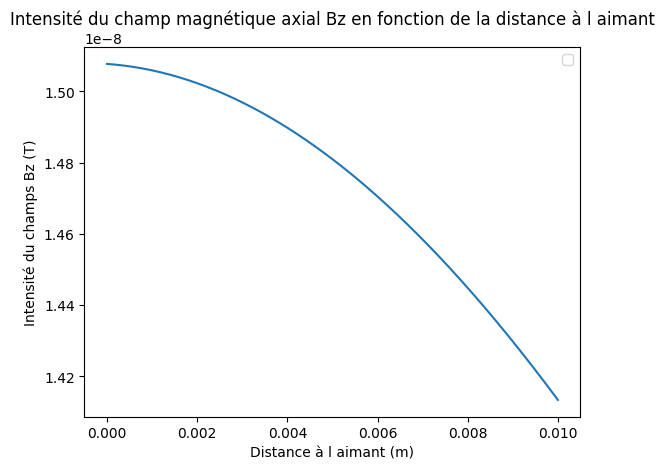

In [4]:
plt.plot(z, Bz_on_axis(z, r, D, Br))
plt.xlabel('Distance à l aimant (m)')
plt.ylabel('Intensité du champs Bz (T)')
plt.title('Intensité du champ magnétique axial Bz en fonction de la distance à l aimant')
plt.legend()
    

Explicitation des champs pour chaque coté (non utiliser pour le calcul)

In [5]:
def B1(z,theta):
    return 20/pi*Bz_on_axis(z,r,D,Br)*np.sin(2*theta)

def B2(z,theta,delta):
    return 20/pi*Bz_on_axis(z,r,D,Br)*np.sin(2*theta-delta)

Calcul de l'énergie magnétique du à chaque aimant (n'est pas source de couple)

In [6]:
E_1 = np.trapz(100*R**2/(pi*mu_0)*Bz_on_axis(z, r, D, Br)**2, z)

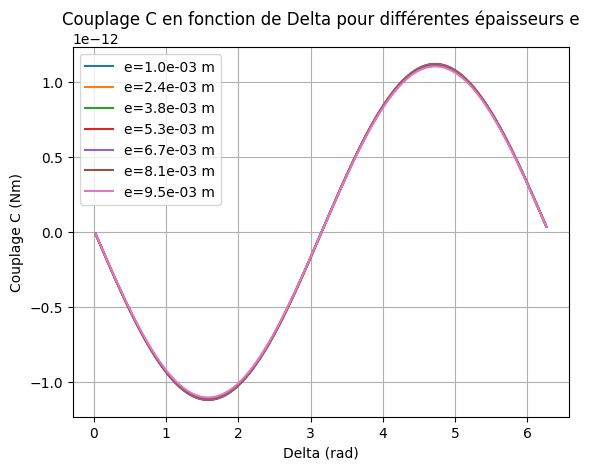

In [11]:
#Energie du à la présence des 2 sources pour un champs.
def E_2(delta,e):
    return 200*R**2/(pi*mu_0)*np.cos(delta)*np.trapz(Bz_on_axis(e-z, r, D, Br)*Bz_on_axis(z, r, D, Br), z)

#Calcul du couple C en fonction du déphasage entre les 2, de l'épaisseur e
e=np.linspace(1e-3,10e-3,20)
delta_values = np.linspace(0, 2*pi, 300)
C_max_values = []
for i,e_k in enumerate(e):
    E2_values = E_2(delta_values,e_k)
    C_values  = []
    for k in range(1, len(delta_values)-1):
        C = (E2_values[k]-E2_values[k-1])/(delta_values[k]-delta_values[k-1])
        C_values.append(C)
    C_max_values.append(max(C_values))
#calcul du maximum du couple pour chaque épaisseur
    if i%3==0:
        plt.plot(delta_values[1:-1], C_values, label=f'e={e_k:.1e} m')
plt.xlabel('Delta (rad)')
plt.ylabel('Couplage C (Nm)')
plt.title('Couplage C en fonction de Delta pour différentes épaisseurs e')
plt.legend()
plt.grid()

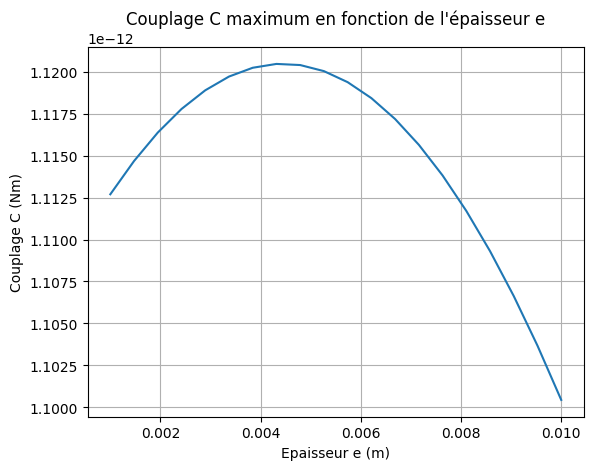

In [12]:
plt.plot(e, C_max_values)
plt.xlabel('Epaisseur e (m)')
plt.ylabel('Couplage C (Nm)')
plt.title('Couplage C maximum en fonction de l\'épaisseur e')
plt.grid()